### 🔧 Step 1: Import Required Libraries

We begin by importing the necessary Python libraries for data handling, visualization, modeling, and evaluation.


In [1]:
!pip install xgboost

In [2]:
try:
    from xgboost import XGBRegressor
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    import joblib



    print("✅ All libraries imported successfully.")
except ImportError as e:
    print(f"❌ Import error: {e}")


✅ All libraries imported successfully.


### 📥 Step 2: Load Player Dataset

We’ll load the main dataset from your local machine.  
Make sure the path is correct and the file is accessible.  
We'll also preview the first few rows to confirm successful loading.


In [3]:
try:
    file_path = r"C:\Users\nadza\OneDrive\Desktop\tactic_sense_app\tactic_sense_app\data\Player_DataFinal.csv"
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("❌ File not found. Please double-check the file path.")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")


❌ File not found. Please double-check the file path.


### 🧾 Step 3: Dataset Overview

We'll display basic information about the dataset:
- Data types and null values
- Basic statistics
- Count of missing values per column
- General data shape


In [4]:
try:
    print("🔍 Dataset Shape:", df.shape)
    print("\n🧠 Data Types and Non-Null Counts:")
    display(df.info())

    print("\n📊 Statistical Summary:")
    display(df.describe())

    print("\n❓ Missing Values per Column:")
    display(df.isnull().sum())
except Exception as e:
    print(f"❌ Error during EDA: {e}")


❌ Error during EDA: name 'df' is not defined


### 🔥 Step 4: Correlation Heatmap

This heatmap helps us identify the strength of linear relationships between numerical features, especially in relation to our target: `market_value`.

We'll use:
- `df.corr(numeric_only=True)` to filter only numeric columns.
- `seaborn` for the heatmap.


In [5]:
try:
    plt.figure(figsize=(12, 6))
    numeric_corr = df.corr(numeric_only=True)

    sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap of Numeric Features")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"❌ Error generating heatmap: {e}")


❌ Error generating heatmap: name 'df' is not defined


<Figure size 1200x600 with 0 Axes>

### 🧠 Step 5: Feature Engineering

We'll create a new **performance_score** feature that combines:
- Goals, Assists, Dribbles, and Mistakes

We’ll also:
- Ensure `position` and `league` are treated as categorical variables
- Check again for missing values


In [6]:
try:
    # Create performance_score using real columns
    df['performance_score'] = (
        df['goals'] * 4 +
        df['assists'] * 3 +
        df['profile_rating'] * 2 +
        df['scouting_score'] +
        df['tactic_fit_score'] -
        df['discipline_score']  # subtracting because more discipline issues = worse
    )

    # Handle categories
    df['position'] = df['position'].astype(str)
    df['league'] = df['league'].astype(str)

    top_positions = df['position'].value_counts().index[:5]
    df['position'] = df['position'].apply(lambda x: x if x in top_positions else 'Other')

    top_leagues = df['league'].value_counts().index[:5]
    df['league'] = df['league'].apply(lambda x: x if x in top_leagues else 'Other')

    print("✅ Feature engineering and category cleanup completed.")
    display(df[['goals', 'assists', 'profile_rating', 'scouting_score', 'discipline_score', 'performance_score']].head())

except Exception as e:
    print(f"❌ Error during feature engineering: {e}")


❌ Error during feature engineering: name 'df' is not defined


### 🎯 Step 6: Define Features (X) and Target (y)

We now isolate:
- `y`: the target variable – player `market_value`
- `X`: the features that will help predict it


In [11]:
try:
    # Load the new dataset
    df = pd.read_csv(r"C:\Users\nadza\OneDrive\Desktop\tactic_sense_app\tactic_sense_app\data\players_dataset.csv")

    # Define the target
    y = df['market_value_eur']

    # Select features based on available columns
    selected_features = [
        'age', 'position', 'league',
        'goals', 'assists',
        'profile_rating', 'scouting_score', 'tactic_fit_score'
    ]
    X = df[selected_features]

    print("✅ Features and target set.")
    display(X.head())
except KeyError as e:
    print(f"❌ One of the selected columns was not found: {e}")
except Exception as e:
    print(f"❌ Error in defining features/target: {e}")



✅ Features and target set.


,age,position,league,goals,assists,profile_rating,scouting_score,tactic_fit_score
0,22,goalkeeper,Nigeria Professional Football League,0.0,0.0,65.12,47.98,90.67
1,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,88.44,64.61,75.48
2,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,73.36,54.05,78.80
3,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,83.66,61.26,66.67
4,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,79.19,58.13,60.75


In [12]:
# Use log1p to avoid log(0) errors
df['log_market_value'] = np.log1p(df['market_value_eur'])

# Update target
y = df['log_market_value']


In [13]:
X = df[['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score', 'position', 'league']]


### 🧪 Step 7: Preprocessing & Modeling Pipeline (XGBoost)

In this step, we:
- Separate numerical and categorical features
- Build a preprocessing pipeline:
    - Standardize numerical features
    - One-hot encode categorical features
- Integrate everything into a full pipeline using `XGBRegressor`



In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# 1. Define numeric and categorical feature lists
numeric_features = ['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score']
categorical_features = ['position', 'league']

# 2. Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# 3. Full pipeline with XGBoost model
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbosity=0
    ))
])

print("✅ XGBoost pipeline created successfully.")


✅ XGBoost pipeline created successfully.


### 🏋️ Step 8: Train/Test Split & Model Training

We:
- Split the data into training and testing sets (80/20)
- Train the full pipeline (preprocessing + XGBoost)
- Target is in **log scale** (`log_market_value`)



In [15]:
from sklearn.model_selection import train_test_split

try:
    # Combine features
    X = df[numeric_features + categorical_features]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train the full pipeline
    pipeline.fit(X_train, y_train)

    print("✅ Model trained successfully with XGBoost and log-transformed target.")
except Exception as e:
    print(f"❌ Error during training: {e}")


✅ Model trained successfully with XGBoost and log-transformed target.


### 📊 Step 9: Model Evaluation (with log-transformed target)

We:
- Predict on the test set (still in log scale)
- Apply `np.expm1()` to get real market values
- Evaluate using MAE, RMSE, and R²
- Visualize predictions vs. actual values


📈 MAE:  938,500.51 EUR
📈 RMSE: 1,383,445.27 EUR
📈 R²:   0.229


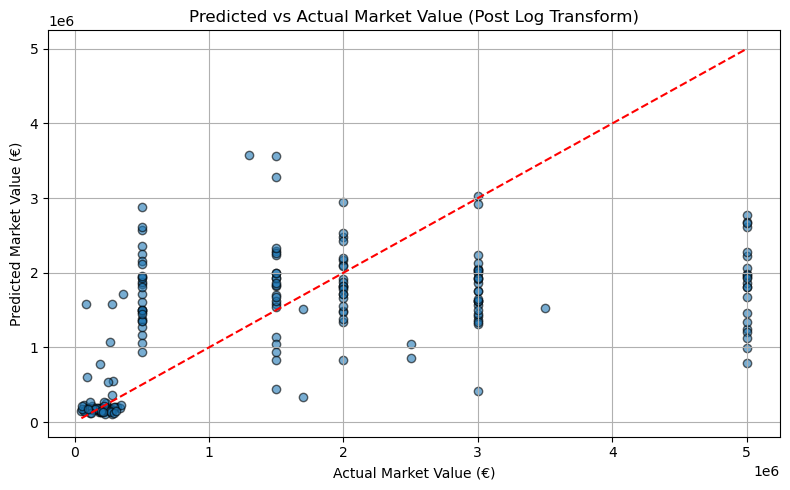

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

try:
    # Predict in log scale
    y_pred_log = pipeline.predict(X_test)

    # Convert back from log scale to real market value
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_actual, y_pred)

    print(f"📈 MAE:  {mae:,.2f} EUR")
    print(f"📈 RMSE: {rmse:,.2f} EUR")
    print(f"📈 R²:   {r2:.3f}")

    # Scatter plot of actual vs predicted
    plt.figure(figsize=(8, 5))
    plt.scatter(y_actual, y_pred, alpha=0.6, edgecolor='k')
    plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
    plt.xlabel("Actual Market Value (€)")
    plt.ylabel("Predicted Market Value (€)")
    plt.title("Predicted vs Actual Market Value (Post Log Transform)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Evaluation failed: {e}")


### 🧪 Step 10: Predict Market Value for a New Player (Custom Input)


In [17]:
try:
    new_player = pd.DataFrame([{
        'age': 21,
        'goals': 10,
        'assists': 5,
        'profile_rating': 8.5,
        'scouting_score': 86,
        'tactic_fit_score': 78,
        'position': 'Forward',
        'league': 'Premier League'
    }])

    predicted_log = pipeline.predict(new_player)[0]
    predicted_value = np.expm1(predicted_log)

    print(f"💸 Predicted Market Value: {predicted_value:,.2f} EUR")
except Exception as e:
    print(f"❌ Prediction failed: {e}")



💸 Predicted Market Value: 2,045,233.50 EUR


### 💾 Step 11: Export Trained XGBoost Model Pipeline


In [18]:
import joblib

try:
    save_path = r"C:\Users\nadza\OneDrive\Desktop\tactic_sense_app\xgb_market_value_model.pkl"
    joblib.dump(pipeline, save_path)
    print(f"✅ Model saved to: {save_path}")
except Exception as e:
    print(f"❌ Error saving model: {e}")


✅ Model saved to: C:\Users\nadza\OneDrive\Desktop\tactic_sense_app\xgb_market_value_model.pkl


### 🧪 Step 14: Predict Market Value for a Single New Player (Custom Input)


In [19]:
test_players = pd.DataFrame([
    {
        'age': 19,
        'goals': 15,
        'assists': 7,
        'profile_rating': 9.2,
        'scouting_score': 91,
        'tactic_fit_score': 88,
        'position': 'Forward',
        'league': 'Premier League'
    },
    {
        'age': 34,
        'goals': 1,
        'assists': 2,
        'profile_rating': 6.0,
        'scouting_score': 48,
        'tactic_fit_score': 39,
        'position': 'Defender',
        'league': 'Other'
    },
    {
        'age': 26,
        'goals': 10,
        'assists': 12,
        'profile_rating': 8.0,
        'scouting_score': 79,
        'tactic_fit_score': 74,
        'position': 'Midfielder',
        'league': 'Turkish Super Lig'
    },
    {
        'age': 28,
        'goals': 0,
        'assists': 0,
        'profile_rating': 3.5,
        'scouting_score': 30,
        'tactic_fit_score': 20,
        'position': 'Other',
        'league': 'Regional Amateur League'
    },
    {
        'age': 25,
        'goals': 2,
        'assists': 1,
        'profile_rating': 5.0,
        'scouting_score': 40,
        'tactic_fit_score': 35,
        'position': 'Midfielder',
        'league': 'Serie B'
    },
    {
        'age': 20,
        'goals': 9,
        'assists': 6,
        'profile_rating': 8.7,
        'scouting_score': 85,
        'tactic_fit_score': 82,
        'position': 'Forward',
        'league': 'Tunisian Ligue 1'
    }
])

# Predict and reverse log transform
try:
    predicted_logs = pipeline.predict(test_players)
    predicted_values = np.expm1(predicted_logs)

    test_players['predicted_market_value_eur'] = predicted_values

    display(test_players[['position', 'league', 'age', 'goals', 'assists', 'profile_rating', 'predicted_market_value_eur']])
except Exception as e:
    print(f"❌ Prediction failed: {e}")


,position,league,age,goals,assists,profile_rating,predicted_market_value_eur
0,Forward,Premier League,19,15,7,9.2,1.927831e+06
1,Defender,Other,34,1,2,6.0,1.425190e+06
2,Midfielder,Turkish Super Lig,26,10,12,8.0,1.072745e+05
3,Other,Regional Amateur League,28,0,0,3.5,1.382920e+06
4,Midfielder,Serie B,25,2,1,5.0,1.375852e+06
5,Forward,Tunisian Ligue 1,20,9,6,8.7,1.917449e+06


In [20]:
try:
    unknown_player = pd.DataFrame([{
        'age': 27,
        'goals': 0,
        'assists': 0,
        'profile_rating': 4.0,
        'scouting_score': 20,
        'tactic_fit_score': 15,
        'position': 'Other',  # intentionally generic
        'league': 'Regional Amateur League'
    }])

    pred_log = pipeline.predict(unknown_player)[0]
    predicted_value = np.expm1(pred_log)

    print(f"🕵️ Predicted Market Value (Unknown Player): {predicted_value:,.2f} EUR")
except Exception as e:
    print(f"❌ Prediction failed: {e}")


🕵️ Predicted Market Value (Unknown Player): 1,382,920.00 EUR
